# Customer Profiling dan Clustering - E-Commerce Dataset

## Penjelasan Awal

Dataset ini berisi transaksi e-commerce di level order (satu baris = satu transaksi). Agar bisa melakukan customer segmentation, kita perlu mengagregasi data ke level customer terlebih dahulu.

Pendekatan yang digunakan:

**1. RFM untuk mengukur nilai customer:**
- Recency: seberapa baru customer melakukan pembelian yang berhasil
- Frequency: seberapa sering customer berhasil menyelesaikan transaksi
- Monetary: total pendapatan bersih dari customer tersebut

**2. Pemisahan data berdasarkan order_status:**
- Value metrics (RFM dan turunannya): hanya dari transaksi dengan status "Selesai"
- Behavior metrics: dari semua transaksi (termasuk Dibatalkan, Dikembalikan, Dalam Pengiriman)

Logika ini penting karena kita tidak ingin menghitung pendapatan dari transaksi yang batal sebagai nilai customer, namun perilaku pembatalan tetap relevan untuk analisis risiko.


## 1. Import Library dan Load Data

In [3]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.titlesize'] = 13


In [4]:
df = pd.read_csv('/kaggle/input/datasets/novitaanggraini02/ecommerce/ecommerce_raw_data.csv')
print(f"Shape awal: {df.shape}")
df.head(3)


Shape awal: (426000, 19)


,order_id,customer_id,order_date,gender,age,city,loyalty_tier,category,product_price,quantity,discount_pct,gross_revenue,discount_value,net_revenue,shipping_cost,payment_method,order_status,rating,registration_date
0,ORD-00306870,CUST-020182,2022-09-18,Female,28.0,Depok,Bronze,Olahraga,531000.0,4,15.0,2123800.0,318600.0,1805300.0,15000.0,Alfamart,Dibatalkan,NaN,2023-04-02
1,ORD-00417200,CUST-027429,2023-05-18,Female,25.0,Palembang,Silver,Electronics,2337800.0,1,15.0,2337800.0,350700.0,1987100.0,9000.0,COD,Selesai,5.0,2022-08-07
2,ORD-00081958,CUST-005529,2022-03-13,Male,25.0,Bogor,Platinum,Electronics,673000.0,1,15.0,673000.0,100900.0,572000.0,9000.0,OVO,Selesai,5.0,2021-01-25


**Hasil:** Dataset memiliki 426.000 baris dan 19 kolom. Setiap baris merepresentasikan satu transaksi, bukan satu customer. Langkah pertama adalah membersihkan data sebelum agregasi.

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 426000 entries, 0 to 425999
Data columns (total 19 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   order_id           426000 non-null  object        
 1   customer_id        426000 non-null  object        
 2   order_date         426000 non-null  datetime64[ns]
 3   gender             426000 non-null  object        
 4   age                426000 non-null  int64         
 5   city               426000 non-null  object        
 6   loyalty_tier       426000 non-null  object        
 7   category           426000 non-null  object        
 8   product_price      426000 non-null  float64       
 9   quantity           426000 non-null  int64         
 10  discount_pct       426000 non-null  float64       
 11  gross_revenue      426000 non-null  float64       
 12  discount_value     426000 non-null  float64       
 13  net_revenue        426000 non-null  float64 

## 2. Data Cleaning

In [5]:
# Cek missing values
print("Missing values per kolom:")
print(df.isnull().sum())


Missing values per kolom:
order_id                  0
customer_id               0
order_date                0
gender                25560
age                   17040
city                  12780
loyalty_tier              0
category                  0
product_price          4260
quantity                  0
discount_pct           6390
gross_revenue             0
discount_value            0
net_revenue               0
shipping_cost          8520
payment_method        10650
order_status              0
rating               108721
registration_date         0
dtype: int64


In [6]:
# Convert datetime
df['order_date'] = pd.to_datetime(df['order_date'], errors='coerce')
df['registration_date'] = pd.to_datetime(df['registration_date'], errors='coerce')

# gender: isi dengan modus per kota (pendekatan kontekstual)
gender_mode = df.groupby('city')['gender'].agg(lambda x: x.mode()[0] if not x.mode().empty else 'Unknown')
df['gender'] = df.apply(
    lambda row: gender_mode.get(row['city'], 'Unknown') if pd.isnull(row['gender']) else row['gender'],
    axis=1
)
df['gender'] = df['gender'].fillna('Unknown')

# age: isi dengan median per loyalty_tier (lebih representatif daripada median global)
df['age'] = df.groupby('loyalty_tier')['age'].transform(lambda x: x.fillna(x.median()))
df['age'] = df['age'].fillna(df['age'].median()).round(0).astype(int)

# city: isi dengan label 'Unknown'
df['city'] = df['city'].fillna('Unknown')

# discount_pct: NaN berarti tidak ada diskon, isi 0
df['discount_pct'] = df['discount_pct'].fillna(0)

# product_price: isi dengan median per kategori
df['product_price'] = df.groupby('category')['product_price'].transform(lambda x: x.fillna(x.median()))

# shipping_cost: isi dengan median per kota
df['shipping_cost'] = df.groupby('city')['shipping_cost'].transform(lambda x: x.fillna(x.median()))
df['shipping_cost'] = df['shipping_cost'].fillna(df['shipping_cost'].median())

# payment_method: isi 'Unknown'
df['payment_method'] = df['payment_method'].fillna('Unknown')

# rating: biarkan NaN - hanya relevan untuk transaksi selesai, tidak akan digunakan di clustering

print("Missing values setelah cleaning:")
print(df.isnull().sum())


Missing values setelah cleaning:
order_id                  0
customer_id               0
order_date                0
gender                    0
age                       0
city                      0
loyalty_tier              0
category                  0
product_price             0
quantity                  0
discount_pct              0
gross_revenue             0
discount_value            0
net_revenue               0
shipping_cost             0
payment_method            0
order_status              0
rating               108721
registration_date         0
dtype: int64


**Hasil:** Semua kolom yang akan digunakan dalam analisis sudah bersih dari missing values. Kolom rating dibiarkan memiliki NaN karena tidak akan dipakai sebagai fitur clustering, rating hanya tersedia untuk transaksi selesai dan tidak setiap transaksi selesai pun memberikan rating.

## 3. Pemisahan Data Berdasarkan Status Transaksi

In [26]:
# Hitung jumlah
status_count = df['order_status'].value_counts()

# Hitung persen
status_percent = df['order_status'].value_counts(normalize=True) * 100

# Gabungkan jadi satu tabel
status_summary = pd.DataFrame({
    'jumlah': status_count,
    'persen (%)': status_percent.round(2)
})

print("Distribusi order_status:")
print(status_summary)

Distribusi order_status:
                  jumlah  persen (%)
order_status                        
Selesai           344868       80.95
Dibatalkan         46785       10.98
Dikembalikan       21449        5.03
Dalam Pengiriman   12898        3.03


In [28]:
df_selesai = df[df['order_status'] == 'Selesai'].copy()
df_all = df.copy()

print(f"Data untuk value metrics (Selesai): {len(df_selesai):,} transaksi")
print(f"Data untuk behavior metrics (semua): {len(df_all):,} transaksi")

Data untuk value metrics (Selesai): 344,868 transaksi
Data untuk behavior metrics (semua): 426,000 transaksi


**Hasil:** Sekitar 81% transaksi berstatus Selesai, 11% Dibatalkan, 5% Dikembalikan, dan 3% Dalam Pengiriman. Data yang selesai akan menjadi basis perhitungan RFM, sementara semua data (termasuk yang batal) dipakai untuk menghitung cancel rate dan perilaku order secara keseluruhan.

## 4. Feature Engineering

In [8]:
# Reference date: satu hari setelah transaksi terakhir
reference_date = df['order_date'].max() + pd.Timedelta(days=1)
print(f"Reference date untuk recency: {reference_date.date()}")


Reference date untuk recency: 2024-06-30


In [29]:
# VALUE FEATURES : hanya dari transaksi Selesai
rfm = df_selesai.groupby('customer_id').agg(
    recency=('order_date', lambda x: (reference_date - x.max()).days),
    frequency=('order_id', 'count'),
    monetary=('net_revenue', 'sum'),
    avg_order_value=('net_revenue', 'mean'),
    total_quantity=('quantity', 'sum')
).reset_index()

print(f"Shape RFM: {rfm.shape}")
rfm.describe().round(2)


Shape RFM: (27983, 6)


,recency,frequency,monetary,avg_order_value,total_quantity
count,27983.00,27983.00,2.798300e+04,27983.00,27983.00
mean,152.18,12.32,6.089651e+06,489594.54,16.51
std,161.10,21.98,1.130283e+07,371728.44,29.59
min,1.00,1.00,7.700000e+03,3850.00,1.00
25%,31.00,3.00,1.002350e+06,253000.00,4.00
50%,94.00,4.00,2.310100e+06,408314.58,6.00
75%,221.00,11.00,5.873200e+06,602704.17,15.00
max,909.00,307.00,1.834749e+08,6464850.00,410.00


In [10]:
# BEHAVIOR FEATURES - dari semua transaksi
behavior = df_all.groupby('customer_id').agg(
    total_order=('order_id', 'count'),
    cancel_count=('order_status', lambda x: (x == 'Dibatalkan').sum()),
    avg_discount=('discount_pct', 'mean'),
    avg_shipping_cost=('shipping_cost', 'mean')
).reset_index()

behavior['cancel_rate'] = (behavior['cancel_count'] / behavior['total_order']).round(4)

print(f"Shape behavior: {behavior.shape}")
behavior.describe().round(2)


Shape behavior: (28000, 6)


,total_order,cancel_count,avg_discount,avg_shipping_cost,cancel_rate
count,28000.00,28000.00,28000.00,28000.00,28000.00
mean,15.21,1.67,10.09,12622.23,0.11
std,27.06,3.20,4.36,2503.37,0.13
min,4.00,0.00,0.00,1800.00,0.00
25%,4.00,0.00,7.50,11250.00,0.00
50%,5.00,1.00,10.00,12600.00,0.08
75%,13.00,2.00,12.50,14000.00,0.20
max,362.00,47.00,40.00,23750.00,1.00


In [11]:
# DEMOGRAPHIC FEATURES - ambil nilai terbaru per customer
demo = df_all.sort_values('order_date').groupby('customer_id').agg(
    gender=('gender', 'first'),
    city=('city', 'first'),
    loyalty_tier=('loyalty_tier', 'first'),
    age=('age', 'first')
).reset_index()

print(f"Shape demo: {demo.shape}")
demo.head(3)


Shape demo: (28000, 5)


,customer_id,gender,city,loyalty_tier,age
0,CUST-000001,Male,Jakarta,Bronze,24
1,CUST-000002,Female,Jakarta,Gold,39
2,CUST-000003,Female,Bandung,Gold,43


In [12]:
# GABUNGKAN SEMUA FITUR
customer_df = demo.merge(rfm, on='customer_id', how='left')
customer_df = customer_df.merge(behavior, on='customer_id', how='left')

# Customer yang tidak punya transaksi selesai: isi value features dengan nilai yang masuk akal
max_recency = (reference_date - df_all.groupby('customer_id')['order_date'].max()).dt.days.max()
customer_df['recency'] = customer_df['recency'].fillna(max_recency)
for col in ['frequency', 'monetary', 'avg_order_value', 'total_quantity']:
    customer_df[col] = customer_df[col].fillna(0)

print(f"Jumlah customer unik: {len(customer_df):,}")
print(f"Missing values: {customer_df.isnull().sum().sum()}")
customer_df.head(3)


Jumlah customer unik: 28,000
Missing values: 0


,customer_id,gender,city,loyalty_tier,age,recency,frequency,monetary,avg_order_value,total_quantity,total_order,cancel_count,avg_discount,avg_shipping_cost,cancel_rate
0,CUST-000001,Male,Jakarta,Bronze,24,173.0,5.0,4764800.0,952960.000000,6.0,5,0,3.000000,12400.000000,0.0000
1,CUST-000002,Female,Jakarta,Gold,39,2.0,56.0,24633900.0,439891.071429,75.0,73,11,9.931507,11315.068493,0.1507
2,CUST-000003,Female,Bandung,Gold,43,42.0,13.0,8718000.0,670615.384615,25.0,14,1,10.000000,12142.857143,0.0714


**Hasil:** Terdapat 28.000 customer unik. Semua fitur sudah terisi tanpa missing values. Customer yang tidak punya transaksi selesai akan memiliki recency maksimum (artinya sudah lama tidak bertransaksi secara berhasil) dan nilai monetary = 0.

## 5. Exploratory Data Analysis (EDA)

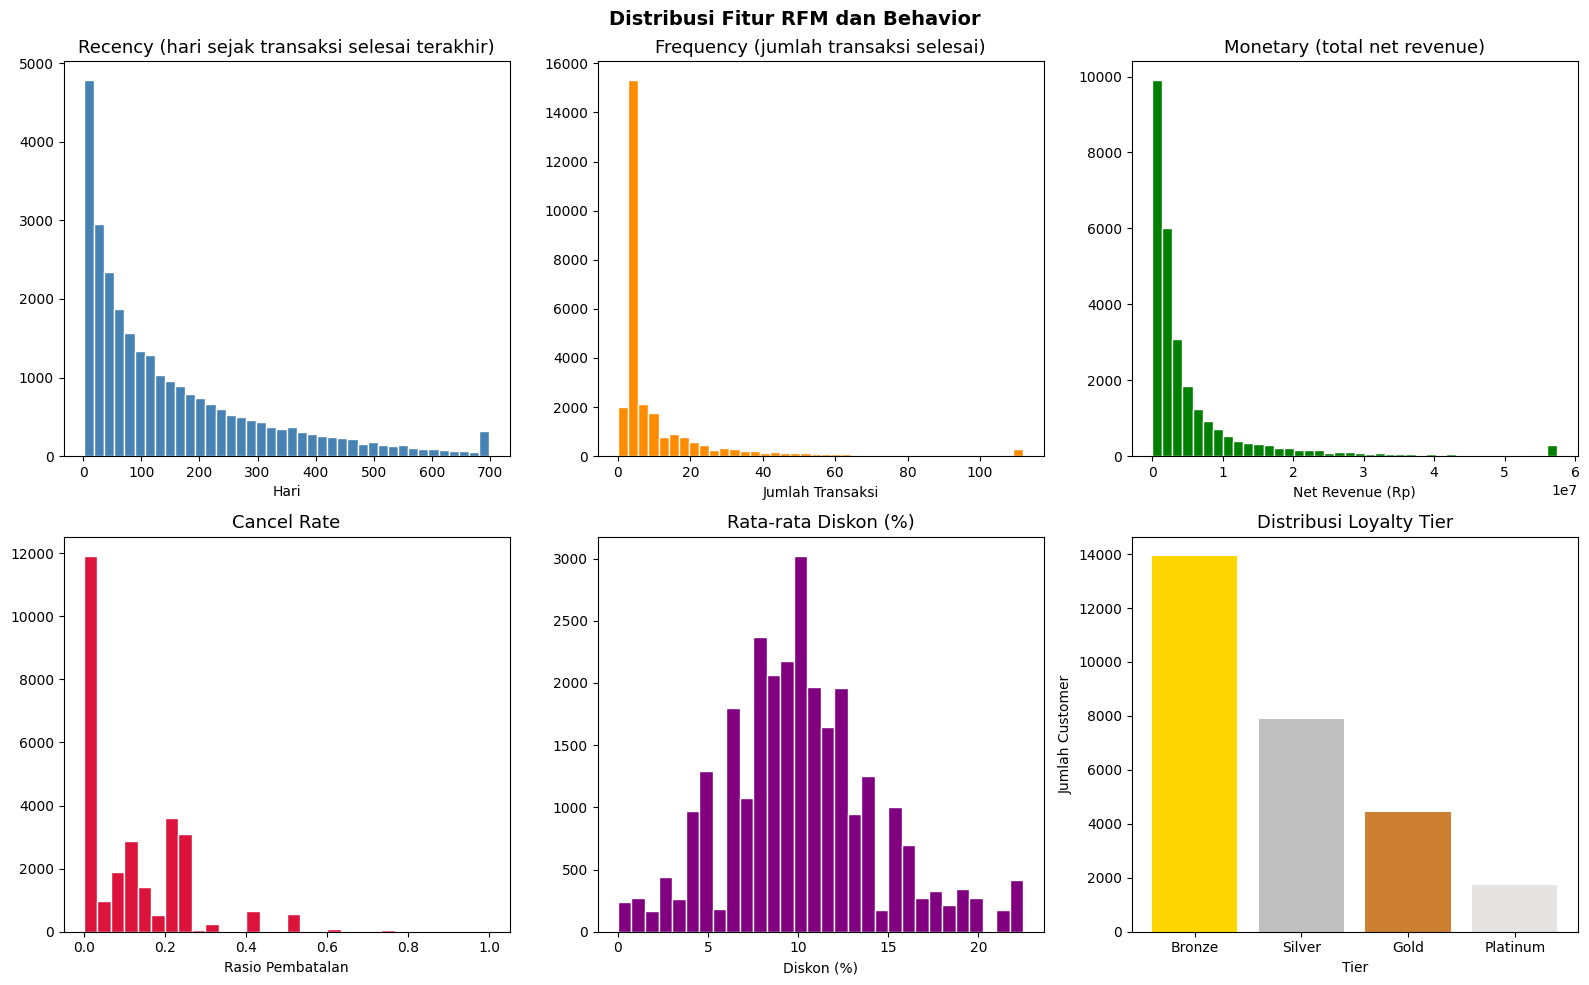

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Distribusi Fitur RFM dan Behavior', fontsize=14, fontweight='bold')

axes[0,0].hist(customer_df['recency'].clip(upper=customer_df['recency'].quantile(0.99)), bins=40, color='steelblue', edgecolor='white')
axes[0,0].set_title('Recency (hari sejak transaksi selesai terakhir)')
axes[0,0].set_xlabel('Hari')

axes[0,1].hist(customer_df['frequency'].clip(upper=customer_df['frequency'].quantile(0.99)), bins=40, color='darkorange', edgecolor='white')
axes[0,1].set_title('Frequency (jumlah transaksi selesai)')
axes[0,1].set_xlabel('Jumlah Transaksi')

axes[0,2].hist(customer_df['monetary'].clip(upper=customer_df['monetary'].quantile(0.99)), bins=40, color='green', edgecolor='white')
axes[0,2].set_title('Monetary (total net revenue)')
axes[0,2].set_xlabel('Net Revenue (Rp)')

axes[1,0].hist(customer_df['cancel_rate'].clip(upper=1.0), bins=30, color='crimson', edgecolor='white')
axes[1,0].set_title('Cancel Rate')
axes[1,0].set_xlabel('Rasio Pembatalan')

axes[1,1].hist(customer_df['avg_discount'].clip(upper=customer_df['avg_discount'].quantile(0.99)), bins=30, color='purple', edgecolor='white')
axes[1,1].set_title('Rata-rata Diskon (%)')
axes[1,1].set_xlabel('Diskon (%)')

loyalty_counts = customer_df['loyalty_tier'].value_counts()
axes[1,2].bar(loyalty_counts.index, loyalty_counts.values, color=['gold','silver','#cd7f32','#e5e4e2'])
axes[1,2].set_title('Distribusi Loyalty Tier')
axes[1,2].set_xlabel('Tier')
axes[1,2].set_ylabel('Jumlah Customer')

plt.tight_layout()
plt.show()


**Insight:**
- Distribusi recency cenderung tersebar merata, menunjukkan customer datang dari berbagai periode aktivitas.
- Frequency dan monetary sangat right-skewed: sebagian besar customer memiliki transaksi yang sedikit dan nilai yang rendah, sementara segelintir customer memiliki transaksi sangat banyak dengan nilai tinggi.
- Cancel rate didominasi oleh nilai 0, artinya mayoritas customer tidak pernah membatalkan. Namun ada kelompok kecil dengan cancel rate yang cukup tinggi dan ini menjadi sinyal penting.

## 6. Data Preparation untuk Clustering

In [14]:
features_for_cluster = [
    'recency', 'frequency', 'monetary', 'avg_order_value',
    'total_quantity', 'total_order', 'cancel_rate',
    'avg_discount', 'avg_shipping_cost'
]

X = customer_df[features_for_cluster].copy()

# StandardScaler agar semua fitur berada di skala yang sama
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Shape data untuk clustering: {X_scaled.shape}")
print("Scaling selesai. Semua fitur kini memiliki mean=0 dan std=1.")


Shape data untuk clustering: (28000, 9)
Scaling selesai. Semua fitur kini memiliki mean=0 dan std=1.


**Hasil:** 9 fitur dipilih untuk clustering, mencakup dimensi nilai (RFM), perilaku (cancel rate, diskon), dan operasional (shipping cost). StandardScaler diperlukan karena K-Means berbasis jarak, tanpa scaling, fitur dengan nilai besar (seperti monetary dalam jutaan rupiah) akan mendominasi dan mengabaikan fitur lain.

## 7. Clustering dengan K-Means

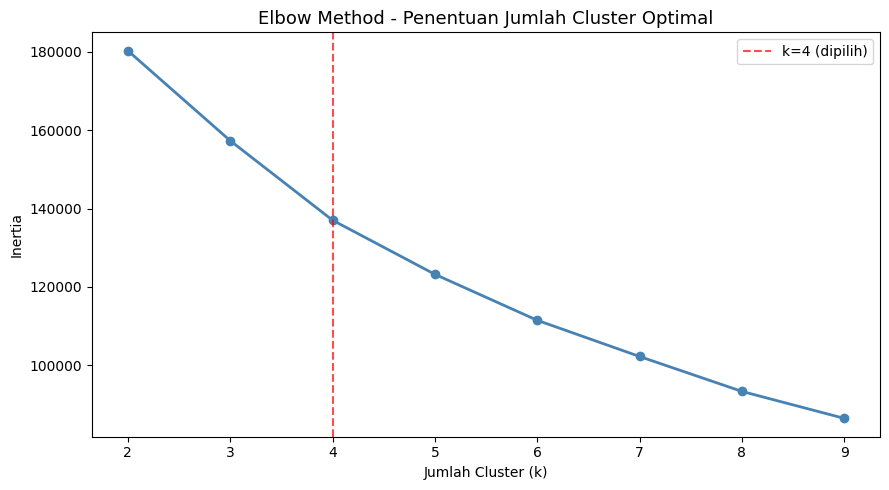

Inertia per k:
  k=2: 180,272
  k=3: 157,318
  k=4: 137,025
  k=5: 123,221
  k=6: 111,484
  k=7: 102,252
  k=8: 93,337
  k=9: 86,461


In [15]:
# Elbow Method untuk menentukan jumlah cluster optimal
inertias = []
k_range = range(2, 10)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(9, 5))
plt.plot(list(k_range), inertias, marker='o', color='steelblue', linewidth=2)
plt.axvline(x=4, color='red', linestyle='--', alpha=0.7, label='k=4 (dipilih)')
plt.title('Elbow Method - Penentuan Jumlah Cluster Optimal')
plt.xlabel('Jumlah Cluster (k)')
plt.ylabel('Inertia')
plt.legend()
plt.tight_layout()
plt.show()

print("Inertia per k:")
for k, inertia in zip(k_range, inertias):
    print(f"  k={k}: {inertia:,.0f}")


Penurunan inertia mulai terasa “landai” di sekitar k=4 sampai k=5. Jadi, k=4 dipilih karena sudah cukup membagi customer ke segmen yang jelas dan berguna, tanpa bikin hasilnya jadi ribet atau sulit dipakai untuk keputusan bisnis.


In [16]:
# Fit K-Means dengan k=4
km_final = KMeans(n_clusters=4, random_state=42, n_init=10)
customer_df['cluster'] = km_final.fit_predict(X_scaled)

print("Distribusi customer per cluster:")
print(customer_df['cluster'].value_counts().sort_index())


Distribusi customer per cluster:
cluster
0     3182
1     8390
2    15890
3      538
Name: count, dtype: int64


## 8. Interpretasi Cluster

In [17]:
# Rata-rata fitur per cluster
cluster_summary = customer_df.groupby('cluster')[features_for_cluster].mean().round(2)
cluster_summary['jumlah_customer'] = customer_df.groupby('cluster').size()
print("Rata-rata fitur per cluster:")
cluster_summary


Rata-rata fitur per cluster:


,recency,frequency,monetary,avg_order_value,total_quantity,total_order,cancel_rate,avg_discount,avg_shipping_cost,jumlah_customer
cluster,,,,,,,,,,
0,23.60,40.75,20634893.84,520058.23,54.88,50.19,0.11,10.03,12636.65,3182
1,224.67,3.99,1928962.06,482390.28,5.35,5.93,0.27,10.06,12604.10,8390
2,145.28,7.03,3362163.05,486220.65,9.35,8.20,0.03,10.12,12630.06,15890
3,8.80,130.06,65311744.61,505944.80,174.87,160.38,0.11,10.07,12588.39,538


In [31]:
# Cluster 3: monetary ~65jt, frequency ~130, recency ~9 hari -> pelanggan terbaik
# Cluster 0: monetary ~20jt, frequency ~41, recency ~24 hari -> pelanggan aktif bernilai tinggi
# Cluster 2: monetary ~3.4jt, frequency ~7, recency ~145 hari -> jarang beli, pasif
# Cluster 1: monetary ~1.9jt, frequency ~4, recency ~225 hari, cancel_rate ~0.27 -> berisiko dan banyak batal

label_map = {
    3: 'Top Spender',
    0: 'High Value Customer',
    2: 'Low Engagement Customer',
    1: 'At Risk Customer'
}
customer_df['cluster_label'] = customer_df['cluster'].map(label_map)

print("Distribusi cluster_label:")
print(customer_df['cluster_label'].value_counts())


Distribusi cluster_label:
cluster_label
Low Engagement Customer    15890
At Risk Customer            8390
High Value Customer         3182
Top Spender                  538
Name: count, dtype: int64


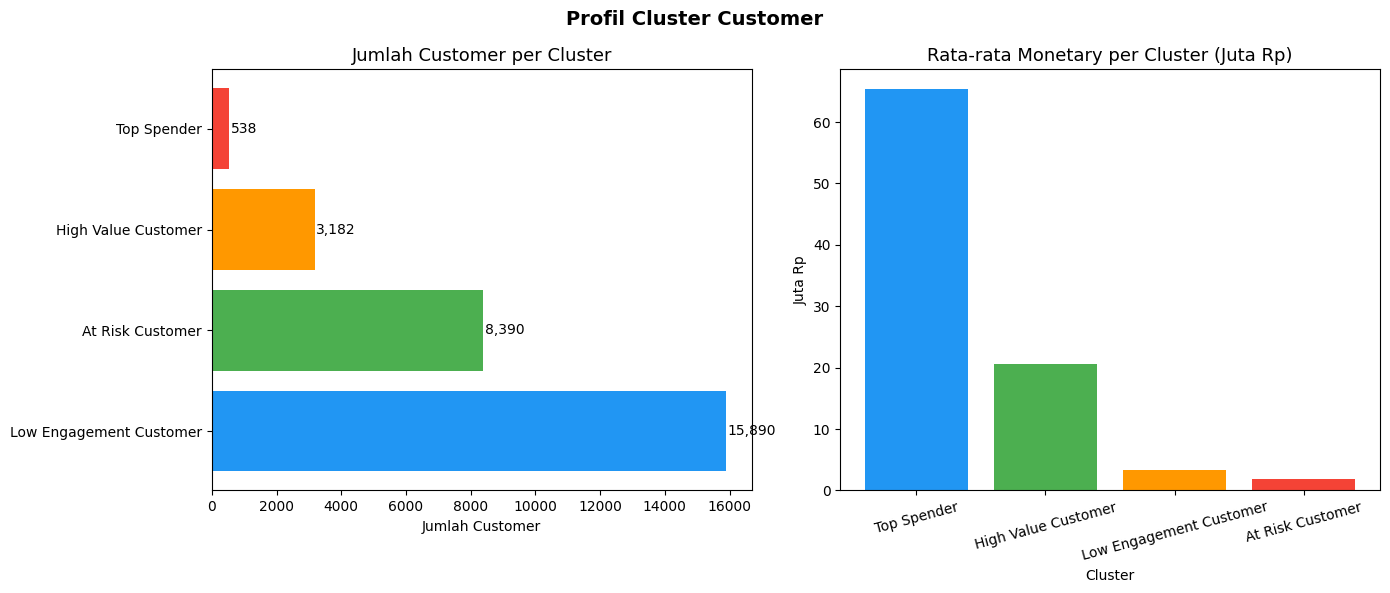

In [19]:
# Visualisasi profil cluster
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Profil Cluster Customer', fontsize=14, fontweight='bold')

cluster_counts = customer_df['cluster_label'].value_counts()
colors_bar = ['#2196F3', '#4CAF50', '#FF9800', '#F44336']

axes[0].barh(cluster_counts.index, cluster_counts.values, color=colors_bar)
axes[0].set_title('Jumlah Customer per Cluster')
axes[0].set_xlabel('Jumlah Customer')
for i, (idx, val) in enumerate(zip(cluster_counts.index, cluster_counts.values)):
    axes[0].text(val + 50, i, f'{val:,}', va='center')

cluster_monetary = customer_df.groupby('cluster_label')['monetary'].mean().sort_values(ascending=False)
axes[1].bar(cluster_monetary.index, cluster_monetary.values / 1e6, color=colors_bar)
axes[1].set_title('Rata-rata Monetary per Cluster (Juta Rp)')
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('Juta Rp')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()


In [32]:
# Tabel ringkasan per cluster
summary_final = customer_df.groupby('cluster_label').agg(
    jumlah_customer=('customer_id', 'count'),
    recency_rata2=('recency', 'mean'),
    frequency_rata2=('frequency', 'mean'),
    monetary_rata2=('monetary', 'mean'),
    cancel_rate_rata2=('cancel_rate', 'mean'),
    avg_order_value_rata2=('avg_order_value', 'mean')
).round(2)

# Tambahin persen customer per cluster
total_customer = summary_final['jumlah_customer'].sum()
summary_final['persen_customer (%)'] = (
    summary_final['jumlah_customer'] / total_customer * 100
).round(2)

# Ubah cancel_rate ke persen
summary_final['cancel_rate_rata2 (%)'] = (
    summary_final['cancel_rate_rata2'] * 100
).round(2)

# Optional: ubah monetary ke juta biar kebaca
summary_final['monetary_rata2_jt'] = (
    summary_final['monetary_rata2'] / 1e6
).round(2)

print("Ringkasan Cluster:")
summary_final

Ringkasan Cluster:


,jumlah_customer,recency_rata2,frequency_rata2,monetary_rata2,cancel_rate_rata2,avg_order_value_rata2,persen_customer (%),cancel_rate_rata2 (%),monetary_rata2_jt
cluster_label,,,,,,,,,
At Risk Customer,8390,224.67,3.99,1928962.06,0.27,482390.28,29.96,27.0,1.93
High Value Customer,3182,23.60,40.75,20634893.84,0.11,520058.23,11.36,11.0,20.63
Low Engagement Customer,15890,145.28,7.03,3362163.05,0.03,486220.65,56.75,3.0,3.36
Top Spender,538,8.80,130.06,65311744.61,0.11,505944.80,1.92,11.0,65.31


### Deskripsi Cluster

**Top Spender (538 customer - 1.9%)**
Customer dengan nilai tertinggi. Rata-rata transaksi selesai mencapai 130 kali dengan total pendapatan bersih sekitar Rp 65 juta per customer. Recency sangat rendah (rata-rata 9 hari), menunjukkan mereka sangat aktif dan konsisten berbelanja. Segmen ini adalah aset terbesar bisnis meskipun jumlahnya kecil.

**High Value Customer (3.182 customer - 11.4%)**
Pelanggan aktif dengan nilai transaksi yang signifikan. Recency rata-rata 24 hari dan frequency 41 transaksi, dengan monetary sekitar Rp 20 juta. Mereka masih aktif dan berpotensi naik ke level Top Spender dengan pendekatan yang tepat.

**Low Engagement Customer (15.890 customer - 56.8%)**
Segmen terbesar namun kurang aktif. Recency rata-rata 145 hari dan frequency hanya 7 transaksi. Nilai monetarynya tergolong rendah (Rp 3.4 juta), namun cancel rate sangat rendah (0.03) yang berarti ketika mereka membeli, transaksi cenderung berhasil. Peluang untuk meningkatkan frekuensi pembelian masih terbuka.

**At Risk Customer (8.390 customer - 30%)**
Pelanggan yang sudah lama tidak aktif (recency 225 hari) dengan nilai rendah dan cancel rate tertinggi (0.27). Ini adalah segmen yang paling berisiko churn. Perlu pendekatan reaktivasi yang terarah dan penanganan khusus untuk mengurangi kebiasaan pembatalan.


## 9. Output Final - CSV Siap Dashboard

In [21]:
final_cols = [
    'customer_id', 'city', 'gender', 'loyalty_tier', 'age',
    'recency', 'frequency', 'monetary', 'avg_order_value', 'total_quantity',
    'total_order', 'cancel_count', 'cancel_rate', 'avg_discount',
    'avg_shipping_cost', 'cluster', 'cluster_label'
]

final_df = customer_df[final_cols].copy()

# Pembulatan untuk keterbacaan dashboard
final_df['recency'] = final_df['recency'].round(0).astype(int)
final_df['frequency'] = final_df['frequency'].round(0).astype(int)
final_df['monetary'] = final_df['monetary'].round(0)
final_df['avg_order_value'] = final_df['avg_order_value'].round(0)
final_df['total_quantity'] = final_df['total_quantity'].round(0).astype(int)
final_df['total_order'] = final_df['total_order'].astype(int)
final_df['cancel_count'] = final_df['cancel_count'].astype(int)
final_df['cancel_rate'] = final_df['cancel_rate'].round(4)
final_df['avg_discount'] = final_df['avg_discount'].round(2)
final_df['avg_shipping_cost'] = final_df['avg_shipping_cost'].round(0)

# Verifikasi kualitas data
print(f"Jumlah baris: {len(final_df):,}")
print(f"Duplikat customer_id: {final_df.duplicated(subset='customer_id').sum()}")
print(f"Missing values: {final_df.isnull().sum().sum()}")
print()
print("Distribusi cluster_label:")
print(final_df['cluster_label'].value_counts())


Jumlah baris: 28,000
Duplikat customer_id: 0
Missing values: 0

Distribusi cluster_label:
cluster_label
Low Engagement Customer    15890
At Risk Customer            8390
High Value Customer         3182
Top Spender                  538
Name: count, dtype: int64


In [22]:
# Simpan CSV
final_df.to_csv('customer_segmentation.csv', index=False)
print("File berhasil disimpan: customer_segmentation.csv")
print(f"Shape: {final_df.shape}")
print()
final_df.head(5)


File berhasil disimpan: customer_segmentation.csv
Shape: (28000, 17)



,customer_id,city,gender,loyalty_tier,age,recency,frequency,monetary,avg_order_value,total_quantity,total_order,cancel_count,cancel_rate,avg_discount,avg_shipping_cost,cluster,cluster_label
0,CUST-000001,Jakarta,Male,Bronze,24,173,5,4764800.0,952960.0,6,5,0,0.0000,3.00,12400.0,2,Low Engagement Customer
1,CUST-000002,Jakarta,Female,Gold,39,2,56,24633900.0,439891.0,75,73,11,0.1507,9.93,11315.0,0,High Value Customer
2,CUST-000003,Bandung,Female,Gold,43,42,13,8718000.0,670615.0,25,14,1,0.0714,10.00,12143.0,2,Low Engagement Customer
3,CUST-000004,Surabaya,Female,Bronze,41,56,8,4622800.0,577850.0,12,10,1,0.1000,5.50,12900.0,2,Low Engagement Customer
4,CUST-000005,Balikpapan,Female,Bronze,28,48,4,2027500.0,506875.0,4,5,1,0.2000,15.00,13400.0,1,At Risk Customer


**Hasil:** File customer_segmentation.csv berisi 28.000 baris unik (satu baris per customer) dengan 17 kolom. Tidak ada duplikasi customer_id dan tidak ada missing values. untuk dibuat dashboard

## 10. Kesimpulan dan Rekomendasi Bisnis

### Ringkasan Segmen

| Segmen | Jumlah | Recency Rata2 | Monetary Rata2 | Cancel Rate |
|---|---|---|---|---|
| Top Spender | 538 (1.9%) | 9 hari | Rp 65.3 juta | 11% |
| High Value Customer | 3.182 (11.4%) | 24 hari | Rp 20.6 juta | 11% |
| Low Engagement Customer | 15.890 (56.8%) | 145 hari | Rp 3.4 juta | 3% |
| At Risk Customer | 8.390 (30%) | 225 hari | Rp 1.9 juta | 27% |

---

### Insight Utama

1. Mayoritas customer (56.8%) berada di segmen Low Engagement - mereka membeli tapi jarang, dan cancel rate-nya justru sangat rendah. Ini adalah segmen yang underutilized: mereka adalah pelanggan yang "baik" tapi belum dimaksimalkan.

2. Segmen At Risk menyumbang 30% customer namun dengan cancel rate 27%, artinya hampir 1 dari 3 order mereka berakhir dibatalkan. Ini menggerus pendapatan secara tidak langsung karena meningkatkan beban operasional (pengembalian, customer service) tanpa menghasilkan revenue.

3. Top Spender hanya 538 orang tapi dengan rata-rata Rp 65.3 juta per customer. Kehilangan satu Top Spender setara dengan kehilangan sekitar 34 Low Engagement Customer dari sisi revenue.

---

### Rekomendasi Actionable

**Retention (High Value Customer dan Top Spender)**
- Berikan akses eksklusif atau program reward yang dipersonalisasi agar segmen ini tidak berpindah ke kompetitor.
- Monitor jika ada High Value Customer yang recency-nya mulai meningkat, itu sinyal awal risiko churn yang perlu ditangani cepat.
- Hindari generalisasi promo untuk Top Spender. Mereka cenderung tidak sensitif harga, sehingga diskon besar justru memangkas margin tanpa menambah nilai.

**Reactivation (Low Engagement Customer)**
- Kirim pengingat atau penawaran yang relevan berdasarkan kategori produk yang pernah dibeli. Personalisasi sederhana sudah cukup untuk segmen ini.
- Coba program "kembali berbelanja" dengan insentif ringan seperti free shipping, bukan diskon besar. Karena cancel rate mereka sudah rendah, masalahnya adalah frekuensi, bukan kepercayaan.
- Identifikasi sub-kelompok dalam segmen ini berdasarkan kategori produk favorit untuk kampanye yang lebih tertarget.

**Handling At Risk Customer**
- Analisis pola pembatalan: apakah pembatalan lebih sering terjadi pada kategori tertentu, metode pembayaran tertentu, atau kota tertentu? Informasi ini membantu menentukan apakah masalahnya ada di sisi operasional (pengiriman lambat, produk tidak sesuai) atau perilaku customer.
- Pertimbangkan penerapan batas cancel rate: misalnya, customer dengan cancel rate di atas ambang tertentu mendapatkan notifikasi atau dibatasi promo tertentu. Ini mengurangi order fiktif yang menguras kapasitas.
- Sebelum menghapus segmen ini sepenuhnya, lakukan satu kampanye reaktivasi sederhana dan ukur hasilnya. Jika tidak ada respons dalam 3 bulan, bisa dipertimbangkan untuk tidak lagi memprioritaskan sumber daya marketing ke segmen ini.
